# NFL Playoff and Conference Final Predictive Models

### Andrew Spika, Lucas Steltenpohl

In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

In [43]:
data = pd.read_csv("nfl_team_stats_2002-2023.csv")

The data comes from the NFL's "hidden" API and consists of each game and game data from seasons 2002 to 2023. These include postseason games. 

In [44]:
df = data.copy()

# Duplicate each row 2 times (resulting in 3 copies of each row)
duplicated_df = df.loc[df.index.repeat(2)].reset_index(drop=True)

# Add 'location' column based on the index
duplicated_df['location'] = ['home' if i % 2 == 0 else 'away' for i in duplicated_df.index]

duplicated_df['team'] = duplicated_df.apply(
    lambda row: row['home'] if row['location'] == 'home' else row['away'], axis=1
)

duplicated_df['opponent'] = duplicated_df.apply(
    lambda row: row['home'] if row['location'] == 'away' else row['away'], axis=1
)


for col in duplicated_df.columns:
    if col.endswith('_home'):
        new_col = col.replace('_home', '_team')
        duplicated_df[new_col] = None

for col in duplicated_df.columns:
    if col.endswith('_away'):
        new_col = col.replace('_away', '_opponent')
        duplicated_df[new_col] = None

# Set '_team' values equal to '_home' values where 'location' is 'home'
for col in duplicated_df.columns:
    if col.endswith('_home'):
        team_col = col.replace('_home', '_team')
        duplicated_df.loc[duplicated_df['location'] == 'home', team_col] = duplicated_df[col]

# Set '_opponent' values equal to '_away' values where 'location' is 'home'
for col in duplicated_df.columns:
    if col.endswith('_away'):
        team_col = col.replace('_away', '_opponent')
        duplicated_df.loc[duplicated_df['location'] == 'home', team_col] = duplicated_df[col]


# Set '_team' values equal to '_home' values where 'location' is 'home'
for col in duplicated_df.columns:
    if col.endswith('_home'):
        team_col = col.replace('_home', '_opponent')
        duplicated_df.loc[duplicated_df['location'] == 'away', team_col] = duplicated_df[col]

# Set '_team' values equal to '_home' values where 'location' is 'home'
for col in duplicated_df.columns:
    if col.endswith('_away'):
        team_col = col.replace('_away', '_team')
        duplicated_df.loc[duplicated_df['location'] == 'away', team_col] = duplicated_df[col]


# Select only '_team', '_opponent', and specified additional columns
selected_columns = ['season', 'week', 'date', 'team', 'opponent', 'location'] + [
    col for col in duplicated_df.columns if col.endswith('_team') or col.endswith('_opponent')
]

new_df = duplicated_df[selected_columns]

We needed to duplicate the each row and reorganize them to have all the stats for a row represent a single team. This worked by renaming and reorganizing the variables that ended in '_home' or '_away' to instead include '_team' or '_opponent' depending on which team was assigned into the new 'team' variable and which team was in the 'opponent' variable. 

In [46]:
new_df['week'].unique()

array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', 'Wildcard', 'Division', 'Conference',
       'Superbowl', '18'], dtype=object)

The types of 'week' variable are from week 1 to 18 and then include the Wildcard, Division, Conference, and Superbowl games as well. 

In [47]:
# Group by 'team' and 'season' and check if 'Conference' is in 'week'
def set_conference_final(group):
    # Check if 'Conference' is in any of the 'week' entries for the group
    if group['week'].str.contains('Conference').any():
        group['made_conference_final'] = True
    else:
        group['made_conference_final'] = False
    return group

# Apply the function to each group
conference_final_teams = new_df.groupby(['team', 'season']).apply(set_conference_final)

def set_superbowl(group):
    # Check if 'Conference' is in any of the 'week' entries for the group
    if group['week'].str.contains('Superbowl').any():
        group['made_superbowl'] = 1
    else:
        group['made_superbowl'] = 0
    return group

superbowl_teams = new_df.groupby(['team', 'season']).apply(set_superbowl)

Using the 'week' variable we are able to find which teams made it to each round of the playoffs and in what years. This is done for the conference final games and superbowl as we plan to explore if these variables can be predicted.

In [48]:
# Adding teams that made the superbowl in for second predictive model
new_df = new_df.groupby(['team', 'season']).apply(set_conference_final)

In [50]:

# Assuming 'data' is your dataset
# Convert 'week' to numeric where possible, keeping non-numeric entries like 'Wild Card', 'Divisional', etc., as NaN
new_df['week_numeric'] = pd.to_numeric(new_df['week'], errors='coerce')

# Calculate the halfway point for each season
halfway_weeks = new_df.groupby('season')['week_numeric'].max() // 2

# Add a column indicating whether the game is before or at the halfway point
new_df['is_halfway'] = new_df.apply(
    lambda row: row['week_numeric'] <= halfway_weeks[row['season']] 
                if not pd.isna(row['week_numeric']) else False, axis=1)

# Engineer 'playoff' column as binary: 1 if 'week_numeric' is missing, 0 otherwise
new_df['playoff'] = new_df['week_numeric'].apply(lambda x: 1 if pd.isna(x) else 0)



The week variable needed to be converted to numeric in order to select the first half of each season based on it. This caused the values of postseason football to be NAs but then these are the teams that made the playoffs. 

In [51]:

# Group by season and team, and check if the team played in any playoff game
new_df['made_playoff'] = new_df.groupby(['season', 'team'])['playoff'].transform('any')

In [ ]:
# Filter the rows where 'is_halfway' is True
first_half = new_df[new_df['is_halfway']]

# Calculate the proportion of wins for each opponent in each season
opponent_win_ratio = (
    first_half
    .groupby(['season', 'opponent'])  # Group by 'season' and 'opponent'
    .apply(lambda group: (group['score_opponent'] > group['score_team']).sum() / len(group))  # Calculate win ratio
    .reset_index(name='opponent_win_ratio')  # Reset index and name the new column
)

# Merge the loss_ratio data back into the first_half DataFrame
first_half = first_half.merge(
    opponent_win_ratio.rename(columns={'opponent': 'opponent', 'opponent_win_ratio': 'opponent_win_ratio'}),
    on=['season', 'opponent'],
    how='left'
)

# Drop the specified columns from first_half
columns_to_drop = ['week', 'date', 'opponent', 'location', 'week_numeric', 'is_halfway', 'playoff']
first_half_removed = first_half.drop(columns=columns_to_drop)

# Define a function to convert MM:SS format to seconds
def convert_to_seconds(time_str):
    minutes, seconds = map(int, time_str.split(':'))
    return minutes * 60 + seconds

# Apply the conversion function to the possession columns
first_half_removed['possession_team_seconds'] = first_half_removed['possession_team'].apply(convert_to_seconds)
first_half_removed['possession_opponent_seconds'] = first_half_removed['possession_opponent'].apply(convert_to_seconds)

# Drop the original possession columns if they are no longer needed
first_half_removed.drop(columns=['possession_team', 'possession_opponent'], inplace=True)

# Display the updated DataFrame
print(first_half_removed.head())


   season        team score_team first_downs_team  \
0    2002      Giants         13               21   
1    2002       49ers         16               13   
2    2002     Jaguars         25               19   
3    2002       Colts         28               18   
4    2002  Commanders         31               21   

  first_downs_from_passing_team first_downs_from_rushing_team  \
0                            17                             2   
1                             7                             5   
2                            11                             8   
3                            13                             5   
4                            13                             8   

  first_downs_from_penalty_team third_down_comp_team third_down_att_team  \
0                             2                    9                  16   
1                             1                    4                  12   
2                             0                    8          

Opponent win ratio, which acts as a strength of schedule variable, is calculated here and the first of the regular season data is filtered to be our data for analysis. 

In [ ]:
#print(first_half_removed.columns)

In [55]:

# Convert all columns except 'team' and 'season' to numeric
first_half_removed.loc[:, ~first_half_removed.columns.isin(['team', 'season'])] = (
    first_half_removed
    .loc[:, ~first_half_removed.columns.isin(['team', 'season'])]
    .apply(pd.to_numeric, errors='coerce')
)

# Group by 'team' and 'season', then compute the average for all other columns
first_half_averages = (
    first_half_removed
    .groupby(['team', 'season'])  # Convert other columns to numeric
    .mean()  # Calculate the mean of all numeric columns
    .reset_index()  # Reset the index
)

# Group by 'season' and 'team', and calculate 'games_won'
games_won = (
    first_half_removed
    .assign(won=lambda df: df['score_team'] > df['score_opponent'])  # Create a boolean column indicating wins
    .groupby(['season', 'team'])['won']  # Group by 'season' and 'team'
    .sum()  # Count the number of True values (i.e., games won)
    .reset_index(name='games_won')  # Reset index and rename the count column to 'games_won'
)

games_lost = (
    first_half_removed
    .assign(lost=lambda df: df['score_team'] < df['score_opponent'])  # Create a boolean column indicating wins
    .groupby(['season', 'team'])['lost']  # Group by 'season' and 'team'
    .sum()  # Count the number of True values (i.e., games won)
    .reset_index(name='games_lost')  # Reset index and rename the count column to 'games_won'
)
# Merge games_won with first_half_average on 'team' and 'season'
merged_df = first_half_averages.merge(games_won, on=['team', 'season'], how='left')
merged_df = merged_df.merge(games_lost, on=['team', 'season'], how='left')


Had to reconvert the numeric columns back to numeric here and created the games won and games lost variables for the first half of the regular season. Then merged these data sets together to get our desired data. 

In [ ]:

# Display the merged DataFrame
merged_df.head()



,team,season,score_team,first_downs_team,first_downs_from_passing_team,first_downs_from_rushing_team,first_downs_from_penalty_team,third_down_comp_team,third_down_att_team,fourth_down_comp_team,...,fumbles_opponent,interceptions_opponent,def_st_td_opponent,made_conference_final,made_playoff,opponent_win_ratio,possession_team_seconds,possession_opponent_seconds,games_won,games_lost
0,49ers,2002,25.714286,20.285714,10.571429,8.571429,1.142857,6.285714,12.000000,0.142857,...,0.714286,1.571429,0.142857,0.0,1.0,0.500000,1790.857143,1809.142857,5,2
1,49ers,2003,21.500000,19.000000,10.250000,7.250000,1.500000,5.500000,14.250000,0.500000,...,1.000000,1.375000,0.000000,0.0,0.0,0.493304,1893.375000,1759.000000,3,5
2,49ers,2004,16.857143,19.285714,12.857143,4.857143,1.571429,5.000000,14.000000,0.714286,...,0.428571,0.428571,0.285714,0.0,0.0,0.535714,1746.142857,1882.857143,1,6
3,49ers,2005,15.857143,11.000000,6.142857,3.714286,1.142857,3.142857,12.142857,0.142857,...,1.000000,1.000000,0.285714,0.0,0.0,0.609694,1533.714286,2066.285714,2,5
4,49ers,2006,19.142857,15.857143,9.000000,5.714286,1.142857,3.857143,12.000000,0.285714,...,0.571429,0.571429,0.428571,0.0,0.0,0.538265,1652.428571,1947.571429,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,Vikings,2019,26.375000,21.625000,10.375000,8.125000,3.125000,5.000000,11.375000,0.500000,...,0.625000,1.000000,0.000000,0.0,1.0,0.395089,1839.500000,1760.500000,6,2
700,Vikings,2020,26.142857,21.857143,10.714286,9.000000,2.142857,3.857143,9.857143,0.714286,...,0.428571,0.428571,0.000000,0.0,0.0,0.586735,1649.571429,1950.428571,2,5
701,Vikings,2021,24.250000,20.500000,12.000000,6.500000,2.000000,5.000000,14.000000,0.750000,...,0.500000,0.875000,0.125000,0.0,0.0,0.539931,1833.750000,1945.750000,3,5
702,Vikings,2022,24.125000,21.750000,13.375000,6.000000,2.375000,5.250000,13.000000,0.375000,...,0.750000,1.000000,0.000000,0.0,1.0,0.461806,1749.125000,1850.875000,7,1


In [57]:
# Drop the 'team' and 'season' variables
first_half_avg = merged_df.drop(columns=['team', 'season'])

We dropped the 'team' and 'season' variables here because we aren't considering them in our model, but for a more complicated model it could be essential to keep these as there are limitations to how many teams can make the playoffs each year. Other factors like conference and division also limit the chances of a team making the playoffs. 

In [ ]:
#first_half_avg.head()
# Save the DataFrame to a CSV file
first_half_avg.to_csv("first_half_avg.csv", index=False)

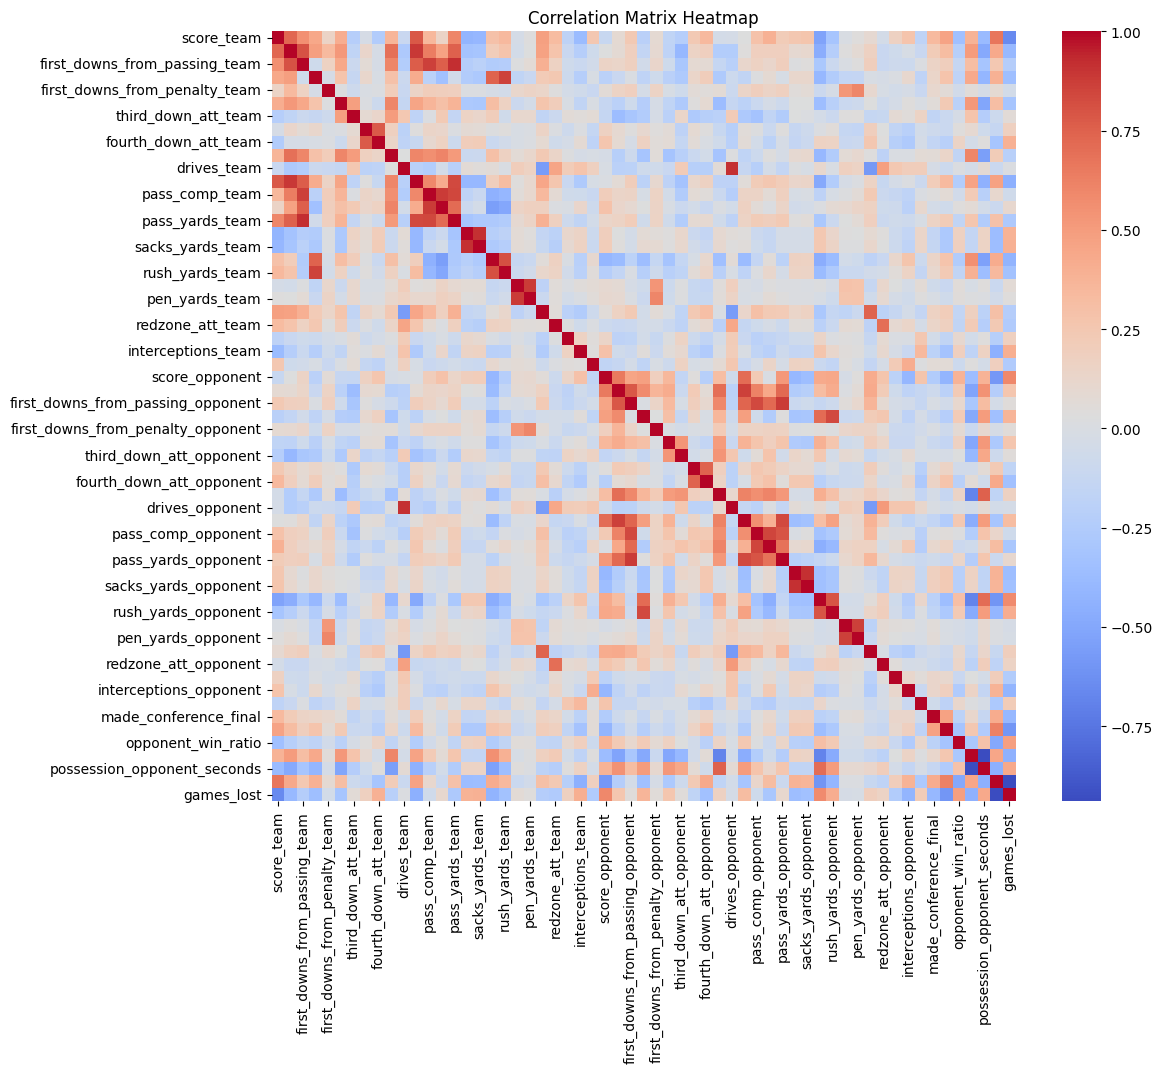

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Matrix Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = first_half_avg.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()


The correlations matrix shown in the heatmap is not an extensive view of all the variables and their correlations but from what can be seen in the heatmap, there are not many very dark shaded red or blue which means that most of the variables have week to no correlation. This is ideal in analysis. 

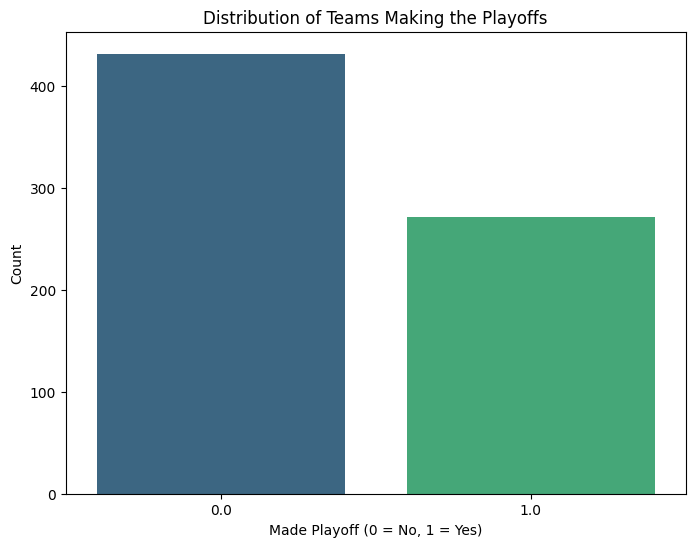

In [110]:
# Distribution of the Target Variable
plt.figure(figsize=(8, 6))
sns.countplot(data=first_half_avg, x='made_playoff', palette='viridis')
plt.title('Distribution of Teams Making the Playoffs')
plt.xlabel('Made Playoff (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

A plot to show the amount of observations we have in the data for teams that made the playoffs and teams that didn't shows slight imbalance, but this is consistent with the rules of the NFL as only 14 teams can make it out of 32 each year.

In [117]:
print(first_half_avg['made_playoff'].mean())
print(first_half_avg['made_conference_final'].mean())


0.38636363636363635
0.125


Among our data set, the proportion of teams that made the playoffs is around 39 percent and the proportion of teams that made the conference final games is 12.5 percent. These are consistent with what is true in the NFL. 

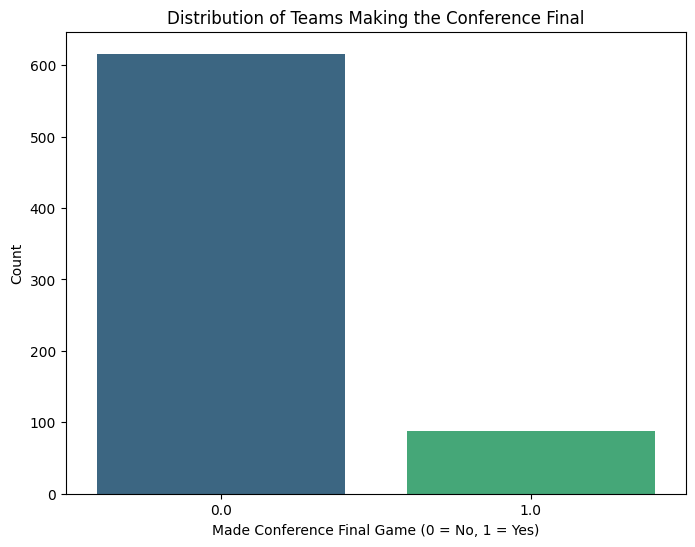

In [119]:
# Distribution of the Target Variable
plt.figure(figsize=(8, 6))
sns.countplot(data=first_half_avg, x='made_conference_final', palette='viridis')
plt.title('Distribution of Teams Making the Conference Final')
plt.xlabel('Made Conference Final Game (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

A similar plot showing the number of teams that made the conference final and missed the conference final shows also that the data is imbalanced in this variable. Again, this is consistent with the NFL as only 4 teams out of 32 make it each year. 

## Fitting Random Forest Classifier model to predict if a team makes the Playoffs

Using a random forest classifier and predicting if a given team made the playoffs based on stats from the first half of the regular season. Using Recursive feature elimination to find the optimal number of features and will then take the teams that are predicted to make the playoffs and predict if they will make it to the conference final game in the playoffs. 

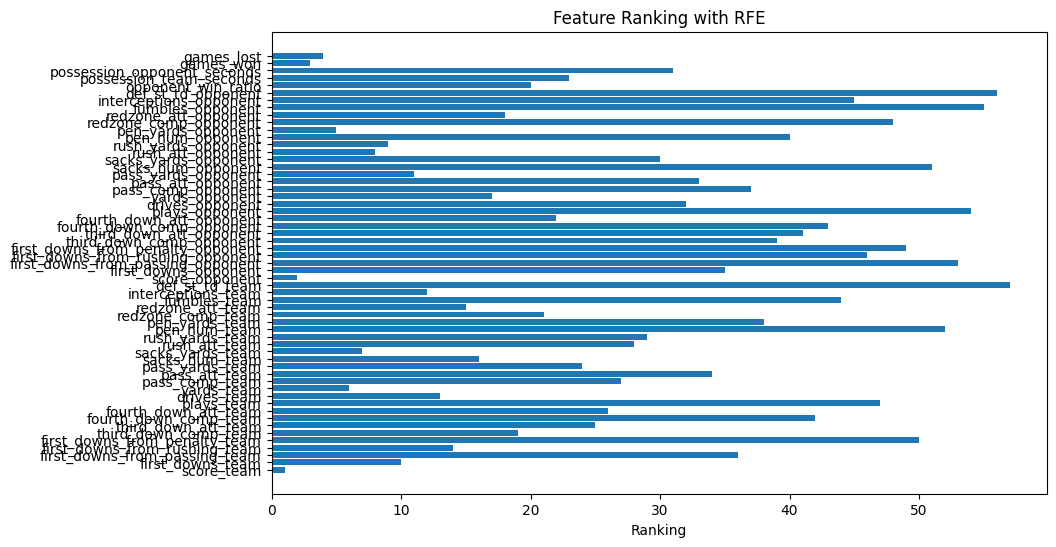

In [118]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Assuming first_half_avg is already loaded and has a 'made_playoff' column as the target variable

# Features (X) and Target (y)
X = first_half_avg.drop(columns=['made_playoff', 'made_conference_final'])
y = first_half_avg['made_playoff']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Use RFE to select the top features
rfe = RFE(estimator=rf_model, n_features_to_select=1)  # Start with selecting 1 feature to rank all
rfe.fit(X_train, y_train)

# Plot the feature ranking
plt.figure(figsize=(10, 6))
plt.barh(X_train.columns, rfe.ranking_)
plt.xlabel('Ranking')
plt.title('Feature Ranking with RFE')
plt.show()



Looping through different numbers of predictors and using RFE to find the most important and the optimal number of features gives the optimal number and which features are most important. Each loop checks the accuracy to determine if the number of features is optimal. Other metrics could be used to find this, but we opted for accuracy for this analysis. The first plot shows the rank of each feature for predicting playoffs based on importance. The lower rank means the higher importance. 

In [ ]:

# Plot the performance as a function of the number of features selected
scores = []
for i in range(1, X_train.shape[1] + 1):
    rfe = RFE(estimator=rf_model, n_features_to_select=i)
    rfe.fit(X_train, y_train)
    selected_features = X_train.columns[rfe.support_]
    rf_model.fit(X_train[selected_features], y_train)
    y_pred = rf_model.predict(X_test[selected_features])
    score = accuracy_score(y_test, y_pred)
    scores.append(score)

# Plot accuracy vs. number of features selected
plt.figure(figsize=(10, 6))
plt.plot(range(1, X_train.shape[1] + 1), scores, marker='o')
plt.xlabel('Number of Features Selected')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Number of Features Selected')
plt.show()

# Select the optimal number of features based on the plot
optimal_num_features = scores.index(max(scores)) + 1
print(f"Optimal number of features selected: {optimal_num_features}")

# Use the optimal number of features to train the final model
rfe = RFE(estimator=rf_model, n_features_to_select=optimal_num_features)
rfe.fit(X_train, y_train)
selected_features = X_train.columns[rfe.support_]

print("Selected Features:", selected_features)

# Train a new Random Forest model using only the selected features
rf_model.fit(X_train[selected_features], y_train)

# Predict on the test set using the selected features
y_pred = rf_model.predict(X_test[selected_features])

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))



In [ ]:
print(optimal_num_features)
# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))



10
Accuracy: 0.7872340425531915
Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.81      0.82        83
         1.0       0.73      0.76      0.75        58

    accuracy                           0.79       141
   macro avg       0.78      0.78      0.78       141
weighted avg       0.79      0.79      0.79       141



The optimal number of features found is 10 for predicting playoffs with this data.

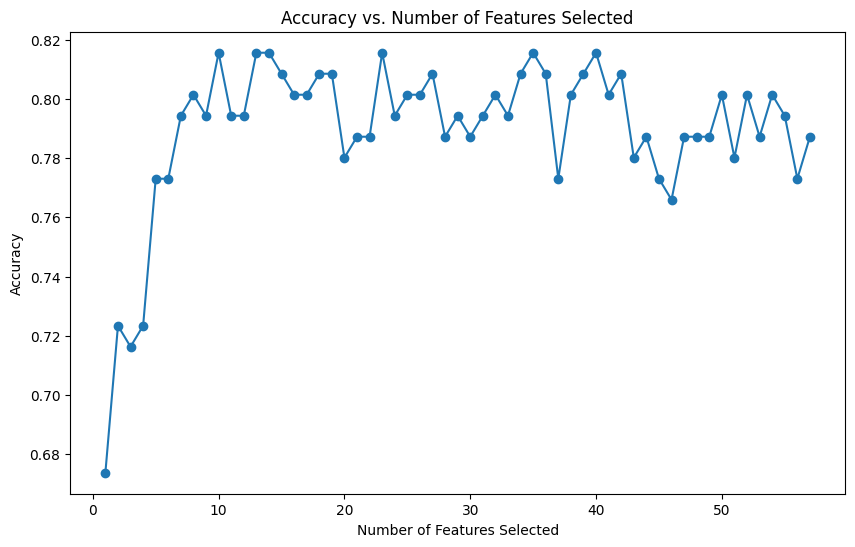

In [ ]:
# Plot accuracy vs. number of features selected
plt.figure(figsize=(10, 6))
plt.plot(range(1, X_train.shape[1] + 1), scores, marker='o')
plt.xlabel('Number of Features Selected')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Number of Features Selected')
plt.show()

It can be seen in the plot above of accuracy score based on number of features selected in the random forest model that the score fluctuates a lot after more than 5 features are used and the first instance of an accuracy above 0.81 occurs with 10 features. There are other points of around this same accuracy, but 10 features is the simplest the model gets while maintaining a high accuracy score.

In [112]:
# 10 component Random Forest Classifier

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data into features and target
X = first_half_avg.drop(columns=['made_playoff', 'made_conference_final'])
y = first_half_avg['made_playoff']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Use RFE to select the top 10 features
rfe = RFE(estimator=rf, n_features_to_select=10)
X_train_rfe = rfe.fit_transform(X_train, y_train)

# Fit the Random Forest model on the selected features
rf.fit(X_train_rfe, y_train)

# Check which features were selected by RFE
selected_features = X.columns[rfe.support_]
print("Selected features:", selected_features)

# Transform the test set using the selected features
X_test_rfe = rfe.transform(X_test)

# Predict on the test set
y_pred = rf.predict(X_test_rfe)

# Evaluate the model (optional)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")



Selected features: Index(['score_team', 'first_downs_team', 'yards_team', 'sacks_yards_team',
       'score_opponent', 'rush_att_opponent', 'rush_yards_opponent',
       'pen_yards_opponent', 'games_won', 'games_lost'],
      dtype='object')
Accuracy: 0.8156028368794326


In [113]:

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.86      0.82      0.84        83
         1.0       0.76      0.81      0.78        58

    accuracy                           0.82       141
   macro avg       0.81      0.81      0.81       141
weighted avg       0.82      0.82      0.82       141



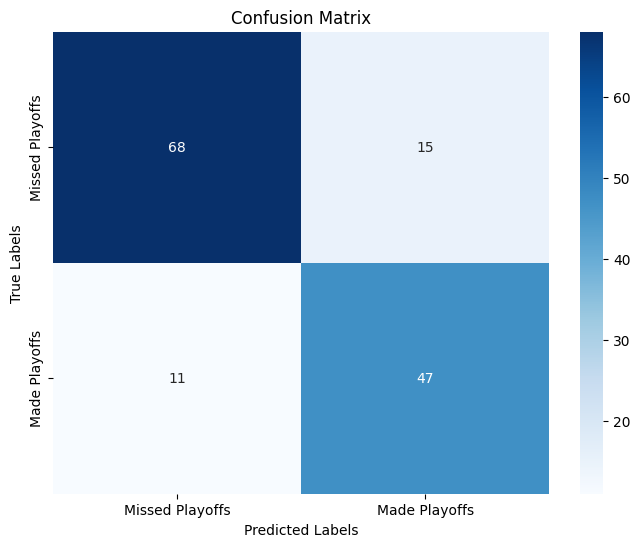

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming y_test and y_pred are defined
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Missed Playoffs", "Made Playoffs"], yticklabels=["Missed Playoffs", "Made Playoffs"])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

For the random forest classifier model, 10 features is found to be the optimal number and gives an accuracy score of about 0.82. This is good for our initial predictive model. Now the predicted rows are taken and used to predict if that team made it to the conference final game during the playoffs. This is done with another model that is trained on only rows that make the playoffs from our original data and the first half statistics contained in those rows.

In [ ]:
results_df = X_test.copy()
results_df['actual_made_playoff'] = y_test
results_df['predicted_made_playoff'] = y_pred

## Predicting if a team will make the Conference Final given they make the playoffs based First Half of the Season data

### Using Random Forest Classifier to Predict whether a team makes the Conference Final

In [22]:
# Filter rows where 'made_playoff' == 1
playoff_teams = first_half_avg[first_half_avg['made_playoff'] == 1]

# Define feature variables (X) and the target variable (y)
X2 = playoff_teams.drop(columns=['made_conference_final', 'made_playoff'])  # Drop irrelevant or target columns
y2 = playoff_teams['made_conference_final']

# Split the data into training and testing sets
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

# Create a Random Forest model
rf_model_2 = RandomForestClassifier(random_state=42)

# Create an RFE selector with the Random Forest model and the desired number of features (e.g., 10)
rfe_selector_2 = RFE(estimator=rf_model_2, n_features_to_select=10)

# Fit the RFE selector to the training data
rfe_selector_2 = rfe_selector_2.fit(X2_train, y2_train)

# Get the selected features
selected_features = X_train.columns[rfe_selector_2.support_]

# Display the selected features
print("Selected Features:", selected_features)

# Train a Random Forest model on the selected features
rf_model_2.fit(X2_train[selected_features], y2_train)

# Evaluate the model on the test set
test_score = rf_model_2.score(X2_test[selected_features], y2_test)

y2_pred = rf_model_2.predict(X2_test[selected_features])



Selected Features: Index(['score_team', 'third_down_att_team', 'pass_att_team', 'pass_yards_team',
       'rush_yards_team', 'score_opponent', 'sacks_yards_opponent',
       'rush_yards_opponent', 'pen_yards_opponent', 'games_won'],
      dtype='object')


In [23]:


print("Random Forest Model Test Accuracy:", test_score)
print("Classification Report:\n", classification_report(y2_test, y2_pred))


Random Forest Model Test Accuracy: 0.6545454545454545
Classification Report:
               precision    recall  f1-score   support

         0.0       0.70      0.84      0.77        37
         1.0       0.45      0.28      0.34        18

    accuracy                           0.65        55
   macro avg       0.58      0.56      0.56        55
weighted avg       0.62      0.65      0.63        55



Attempting the second model for predicting playoffs with 10 features and training data derived from all the playoff teams in our initial data set gives an accuracy of 0.65. This is not excellent and suggests that maybe 10 features isn't the optimal number for this analysis. 

### Optimizing such as with the First Model

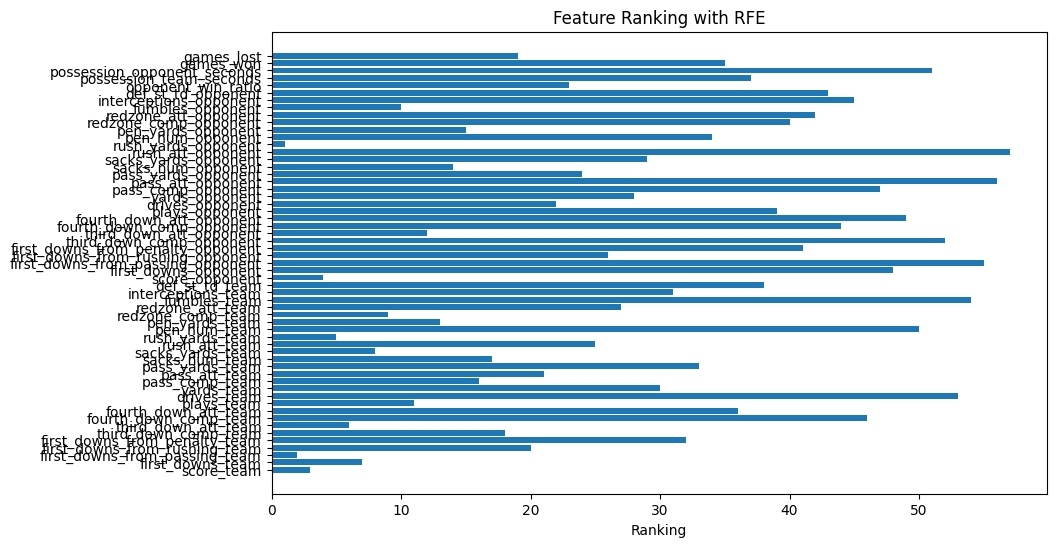

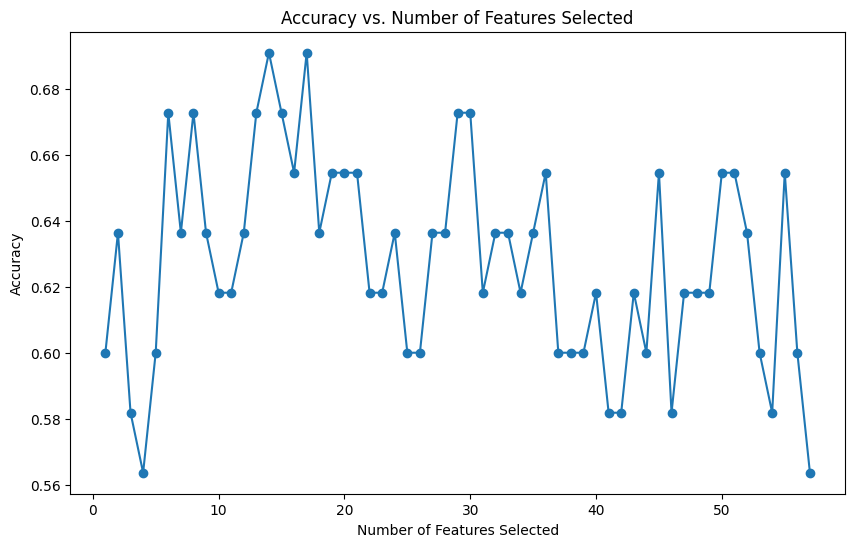

Optimal number of features selected: 14
Selected Features: Index(['score_team', 'first_downs_team', 'first_downs_from_passing_team',
       'third_down_att_team', 'plays_team', 'sacks_yards_team',
       'rush_yards_team', 'pen_yards_team', 'redzone_comp_team',
       'score_opponent', 'third_down_att_opponent', 'sacks_num_opponent',
       'rush_yards_opponent', 'fumbles_opponent'],
      dtype='object')
Accuracy: 0.6909090909090909
Classification Report:
              precision    recall  f1-score   support

         0.0       0.65      1.00      0.79        32
         1.0       1.00      0.26      0.41        23

    accuracy                           0.69        55
   macro avg       0.83      0.63      0.60        55
weighted avg       0.80      0.69      0.63        55



In [ ]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Assuming first_half_avg is already loaded and has a 'made_playoff' column as the target variable
playoff_teams = first_half_avg[first_half_avg['made_playoff'] == 1]

# Features (X) and Target (y)
X = playoff_teams.drop(columns=['made_playoff', 'made_conference_final'])
y = playoff_teams['made_conference_final']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Use RFE to select the top features
rfe = RFE(estimator=rf_model, n_features_to_select=1)  # Start with selecting 1 feature to rank all
rfe.fit(X_train, y_train)

# Plot the feature ranking
plt.figure(figsize=(10, 6))
plt.barh(X_train.columns, rfe.ranking_)
plt.xlabel('Ranking')
plt.title('Feature Ranking with RFE')
plt.show()

# Plot the performance as a function of the number of features selected
scores = []
for i in range(1, X_train.shape[1] + 1):
    rfe = RFE(estimator=rf_model, n_features_to_select=i)
    rfe.fit(X_train, y_train)
    selected_features = X_train.columns[rfe.support_]
    rf_model.fit(X_train[selected_features], y_train)
    y_pred = rf_model.predict(X_test[selected_features])
    score = accuracy_score(y_test, y_pred)
    scores.append(score)



# Select the optimal number of features based on the plot
optimal_num_features = scores.index(max(scores)) + 1
print(f"Optimal number of features selected: {optimal_num_features}")

# Use the optimal number of features to train the final model
rfe = RFE(estimator=rf_model, n_features_to_select=optimal_num_features)
rfe.fit(X_train, y_train)
selected_features = X_train.columns[rfe.support_]

print("Selected Features:", selected_features)

# Train a new Random Forest model using only the selected features
rf_model.fit(X_train[selected_features], y_train)

# Predict on the test set using the selected features
y_pred = rf_model.predict(X_test[selected_features])

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

By optimizing this second model as we did with the first one, the optimal number of features turned out to be 14 and the accuracy obtained was 0.69. This is slightly better. 

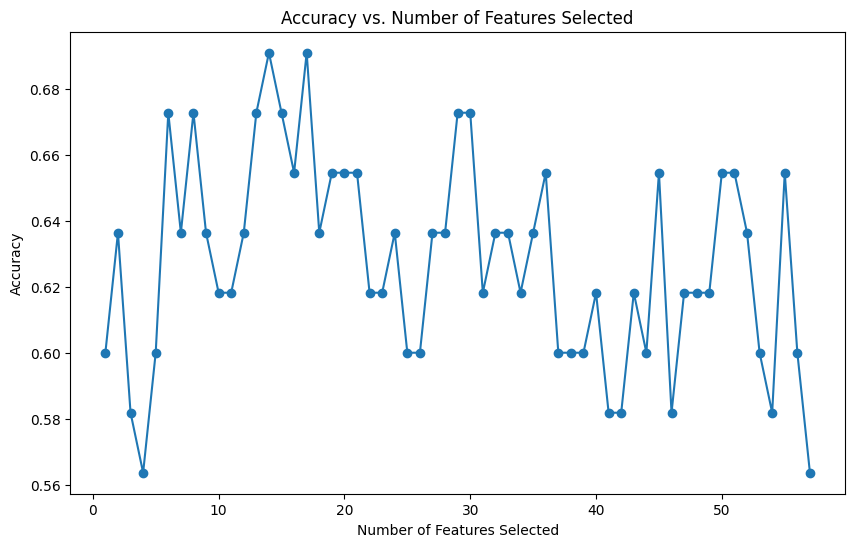

In [ ]:
# Plot accuracy vs. number of features selected
plt.figure(figsize=(10, 6))
plt.plot(range(1, X_train.shape[1] + 1), scores, marker='o')
plt.xlabel('Number of Features Selected')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Number of Features Selected')
plt.show()

The optimal number of features in the second model to predict if the team will make it to the conference final is 14. This model, with the testing data, gives an accuracy of 0.69, weighted average precision of 0.83, and weighted average recall of 0.69. The plot shows the variation in accuracy as the number of features selected increases. The max occurs at this 14 feature value and this is the simplest the model can get while still maintaining the highest accuracy possible. 

### Using Logistic Regression to Predict Conference Final

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Filter rows where 'made_playoff' == 1
playoff_teams = first_half_avg[first_half_avg['made_playoff'] == 1]

# Define feature variables (X2) and the target variable (y2)
X2 = playoff_teams.drop(columns=['made_conference_final', 'made_playoff'])  # Drop irrelevant or target columns
y2 = playoff_teams['made_conference_final']

# Split the data into training and testing sets
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Create a Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Perform RFECV to find the optimal number of features
rfecv = RFECV(estimator=logistic_model, step=1, cv=5, scoring='accuracy', min_features_to_select=1)
rfecv.fit(X2_train, y2_train)

# Get the optimal number of features and their names
optimal_features = X2_train.columns[rfecv.support_]
optimal_num_features = rfecv.n_features_

print("Optimal Number of Features:", optimal_num_features)
print("Selected Features:", optimal_features)

# Train the Logistic Regression model using the optimal features
logistic_model.fit(X2_train[optimal_features], y2_train)

# Evaluate the model on the test set
y2_pred = logistic_model.predict(X2_test[optimal_features])
test_accuracy = accuracy_score(y2_test, y2_pred)

print("Logistic Regression Model Test Accuracy:", test_accuracy)




Optimal Number of Features: 10
Selected Features: ['third_down_att_team', 'plays_team', 'pass_att_team', 'rush_att_team',
       'fumbles_team', 'first_downs_from_penalty_opponent',
       'fourth_down_att_opponent', 'fumbles_opponent', 'def_st_td_opponent',
       'games_won']

In [ ]:


print("Logistic Regression Model Test Accuracy:", test_accuracy)
print("Classification Report:\n", classification_report(y2_test, y2_pred))

Logistic Regression Model Test Accuracy: 0.5454545454545454
Classification Report:
               precision    recall  f1-score   support

         0.0       0.57      0.84      0.68        32
         1.0       0.38      0.13      0.19        23

    accuracy                           0.55        55
   macro avg       0.47      0.49      0.44        55
weighted avg       0.49      0.55      0.48        55



In a logistic regression model, the optimal number of features is 10, and this gives an accuracy of only 0.55 compared to the accuracy of 0.69 from the random forest classifier when predicting if the playoff team will make the conference final game. 

### Using the models together

In [91]:
# Selected features for the first model
first_model_selected_features = ['score_team', 'first_downs_team', 'yards_team', 'sacks_yards_team',
       'score_opponent', 'rush_att_opponent', 'rush_yards_opponent',
       'pen_yards_opponent', 'games_won', 'games_lost']

# Selected features for the second model
second_model_selected_features = ['score_team', 'first_downs_team', 'first_downs_from_passing_team',
       'third_down_att_team', 'plays_team', 'sacks_yards_team',
       'rush_yards_team', 'pen_yards_team', 'redzone_comp_team',
       'score_opponent', 'third_down_att_opponent', 'sacks_num_opponent',
       'rush_yards_opponent', 'fumbles_opponent']

playoff_teams = first_half_avg[first_half_avg['made_playoff'] == 1]

X_1 = first_half_avg
y_1 = first_half_avg['made_playoff']

X1_train, X1_test, y1_train, y1_test = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

# Only the made_playoff values form X_1
X2_train = X1_train[X1_train['made_playoff'] == 1]
# y_2 will hold values from 'made_conference_final' for matching indexes
y2_train = X2_train.loc[X2_train.index, 'made_conference_final']

#X_2 = playoff_teams.drop(columns=['made_playoff', 'made_conference_final'])
#y_2 = playoff_teams['made_conference_final']

#X2_train, X2_test, y2_train, y2_test = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

# initialize and fit model 1
rf_mod_1 = RandomForestClassifier(random_state=42)
rf_mod_1.fit(X1_train[first_model_selected_features], y1_train)

# initialize and fit model 2
rf_mod_2 = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_mod_2.fit(X2_train[second_model_selected_features], y2_train)

# Test the performance of both models
y1_pred = rf_mod_1.predict(X1_test[first_model_selected_features])
print(classification_report(y1_pred, y1_test))



              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84        79
         1.0       0.81      0.76      0.78        62

    accuracy                           0.82       141
   macro avg       0.81      0.81      0.81       141
weighted avg       0.82      0.82      0.81       141



Now, putting the models together, both models are fit. This time however, because we don't want to train the second model for predicting conference final game appearances with data that will be used to test the accuracy of both models together, the training data of playoff teams included in the training of the first model will be used instead of all playoff teams from the initial first half data. This will ensure more validity of testing results. 

In [ ]:
# Obtain the Teams that are predicted to make playoffs based on first model
# Run these teams through the second model
results_1 = X1_test.copy()
results_1['predicted_made_playoff'] = y1_pred
results_1['made_conference_final'] = results_1.index.map(first_half_avg['made_conference_final'])

# Filter the data frame
playoff_results_1 = results_1[results_1['predicted_made_playoff'] == 1]


The testing data is then run through the first model and the predicted rows for making playoffs are run through the second model to test if they also made the conference final game. Then these predictions are referenced back to the original data to test the accuracy of the chained models. 

In [95]:
# Run these teams through the next 
y2_pred = rf_mod_2.predict(playoff_results_1[second_model_selected_features])

print(classification_report(y2_pred, playoff_results_1['made_conference_final']))

              precision    recall  f1-score   support

         0.0       0.93      0.75      0.83        53
         1.0       0.32      0.67      0.43         9

    accuracy                           0.74        62
   macro avg       0.62      0.71      0.63        62
weighted avg       0.84      0.74      0.77        62



This gives an overall accuracy of predicting if a team will make the conference final or not of 0.74. The precision for predicting a successful outcome of making the conference final in the two models is only 0.32, however. Considering it is a difficult task to predict given that the season is only half way through when predictions are being made, this seems like a relatively strong prediction. 

## PCA

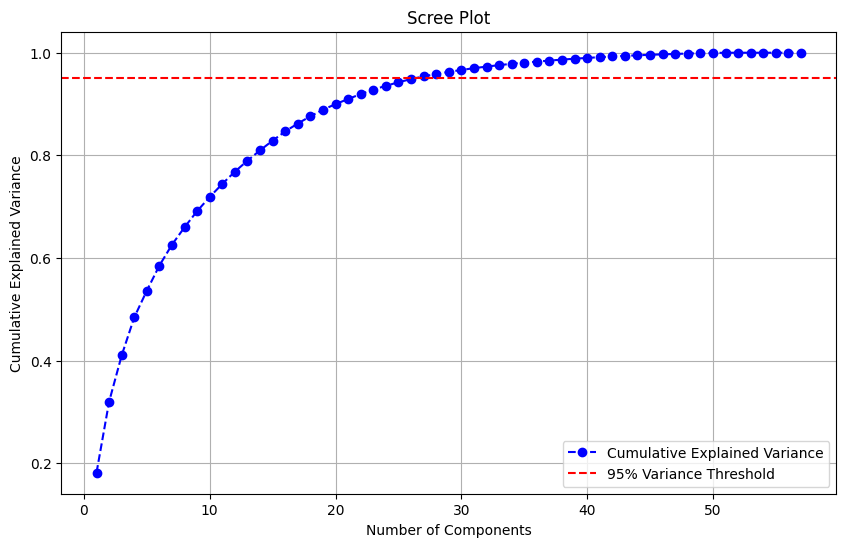

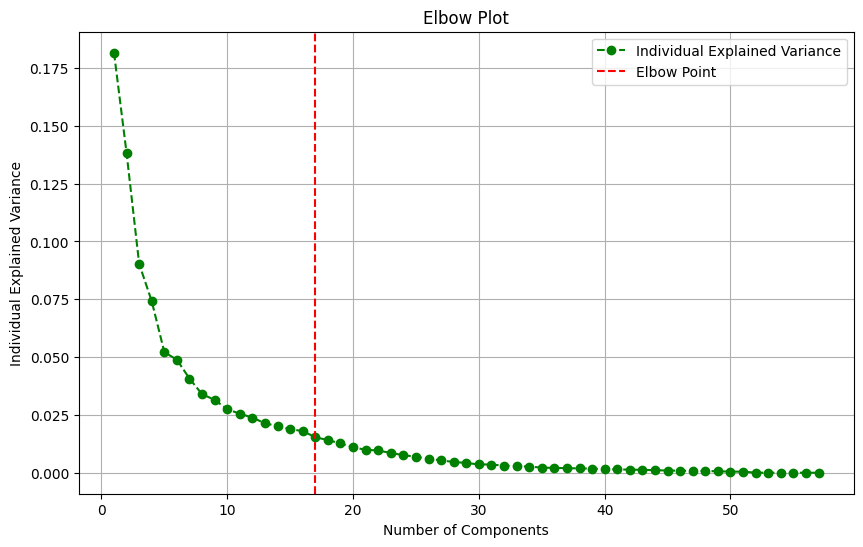

Number of components based on cumulative variance (95% threshold): 27
Number of components based on elbow method: 17
Using 27 components for PCA.
Accuracy with PCA and Random Forest: 0.7730496453900709


In [99]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Split data into features and target
X = first_half_avg.drop(columns=['made_playoff', 'made_conference_final'])
y = first_half_avg['made_playoff']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate explained variance ratio and cumulative explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Scree plot (cumulative explained variance)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--', color='b', label='Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.grid()
plt.legend()
plt.show()

# Elbow plot (individual explained variance per component)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', color='g', label='Individual Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Individual Explained Variance')
plt.title('Elbow Plot')
plt.axvline(x=np.argmax(explained_variance_ratio < explained_variance_ratio.mean()) + 1, color='r', linestyle='--', label='Elbow Point')
plt.grid()
plt.legend()
plt.show()

# Select the number of components based on 95% cumulative variance
n_components_cumulative = np.argmax(cumulative_explained_variance >= 0.95) + 1
print(f"Number of components based on cumulative variance (95% threshold): {n_components_cumulative}")

# Select the number of components based on the elbow method (variance drops below average)
n_components_elbow = np.argmax(explained_variance_ratio < explained_variance_ratio.mean()) + 1
print(f"Number of components based on elbow method: {n_components_elbow}")

# Use the number of components based on your chosen method
n_components = n_components_cumulative  # You can switch to n_components_elbow if preferred
print(f"Using {n_components} components for PCA.")

# Reduce the dataset to the selected number of components
pca = PCA(n_components=n_components)
X_reduced = pca.fit_transform(X_scaled)

# Split the reduced data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

# Train a Random Forest model on the PCA-transformed data
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predict on the test set
y_pred = rf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with PCA and Random Forest: {accuracy}")


PCA was also attempted to see if it was a better way to reduce data dimensions and predict if a team will make the playoffs. The elbow method wasn't very useful with this PCA as the number of components didn't show a clear elbow and the variance didn't accumulate very efficiently with 95 percent of the variation not being explained until 27 components were taken. With these 27 components, the random forst only got an accuracy of 77 percent. 

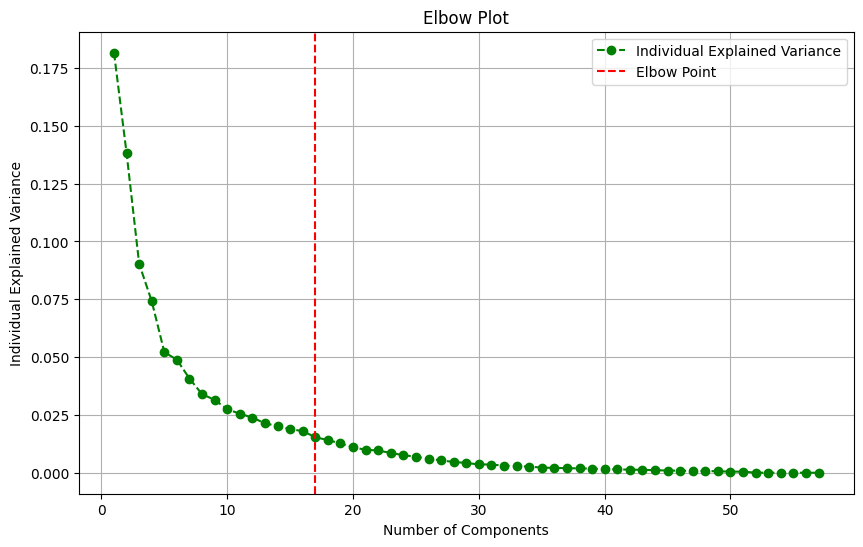

In [100]:
# Elbow plot (individual explained variance per component)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', color='g', label='Individual Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Individual Explained Variance')
plt.title('Elbow Plot')
plt.axvline(x=np.argmax(explained_variance_ratio < explained_variance_ratio.mean()) + 1, color='r', linestyle='--', label='Elbow Point')
plt.grid()
plt.legend()
plt.show()

The expected elbow point of this plot is at 17 components, but the elbow isn't very clear and not too much variance is explained by only 17 components. 

In [101]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with PCA and Random Forest: {accuracy}")

Accuracy with PCA and Random Forest: 0.7730496453900709


### 5 Feature Model to predict Current NFL teams

Selected features: Index(['score_team', 'score_opponent', 'pen_yards_opponent', 'games_won',
       'games_lost'],
      dtype='object')
              Feature  Importance
3           games_won    0.231221
0          score_team    0.223822
1      score_opponent    0.209836
4          games_lost    0.168673
2  pen_yards_opponent    0.166447


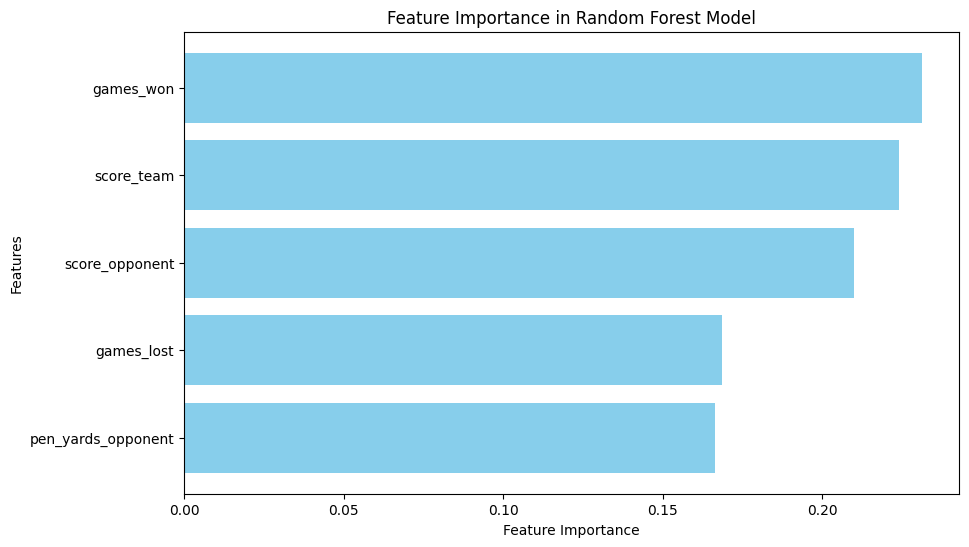

Accuracy: 0.7730496453900709


In [97]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Split data into features and target
X = first_half_avg.drop(columns=['made_playoff', 'made_conference_final'])
y = first_half_avg['made_playoff']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Use RFE to select the top 5 features
rfe = RFE(estimator=rf, n_features_to_select=5)
X_train_rfe = rfe.fit_transform(X_train, y_train)

# Fit the Random Forest model on the selected features
rf.fit(X_train_rfe, y_train)

# Check which features were selected by RFE
selected_features = X.columns[rfe.support_]
print("Selected features:", selected_features)

# Get feature importances
importances = rf.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the feature importances
print(feature_importance_df)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # Reverse the order for better readability
plt.show()

# Transform the test set using the selected features
X_test_rfe = rfe.transform(X_test)

# Predict on the test set
y_pred = rf.predict(X_test_rfe)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


We wanted to see how a simplified model would work on data from the current NFL season. We used a random forest classifier with 5 components as this is the strongest model we could do without having to manually find many statistics. The importance of the 5 features used is in the barplot above and the accuracy of the model in testing was 77 percent. 

2024 Packers Halfway Season Average Statistics:
- Team Score: 24
- Opponent Score: 21.25
- Opponent Penalty Yards: 48.875
- Games Won: 6
- Games Lost: 2

2024 Lions Halfway Season Average Statistics:
- Team Score: 32.25
- Opponent Score: 18.5
- Opponent Penalty Yards: 50.125
- Games Won: 7
- Games Lost: 1

In [90]:
packers_data = pd.DataFrame({
    'score_team': [27], 
    'score_opponent': [21.25],
    'pen_yards_opponent': [48.875],
    'games_won': [6],
    'games_lost': [2]
})

lions_data = pd.DataFrame({
    'score_team': [32.35],
    'score_opponent': [18.5],
    'pen_yards_opponent': [50.125],
    'games_won': [7],
    'games_lost': [1]
})

print(rf.predict(packers_data))
print(rf.predict(lions_data))

[1.]
[1.]


Using the data for the Packers and Lions halfway through the 2024 NFL season, both of which are expected to make the playoffs in reality, gave us predictions that also said they would each make the playoffs. 